In [16]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

# Khai báo đường dẫn module gốc
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise

# =====================================================================
# 1. ĐẦU VÀO (INPUT)
# =====================================================================
print("Đang khởi tạo dữ liệu và bơm nhiễu...")

# Lấy trục X của Lorenz và bơm nhiễu trắng (SNR = 15 dB)
lorenz_data = simulate_lorenz(t_span=100.0, dt=0.01)
clean_x = lorenz_data[0]
noisy_x = add_white_noise(clean_x, snr_db=30.0)
N_T = len(noisy_x)

Đang khởi tạo dữ liệu và bơm nhiễu...


Đang chạy Quadtree quét qua các độ trễ T (có thể mất vài giây)...
--> [KẾT QUẢ] Độ trễ T tối ưu (Cực tiểu đầu tiên) là: T = 16 (tương ứng 0.16 giây)


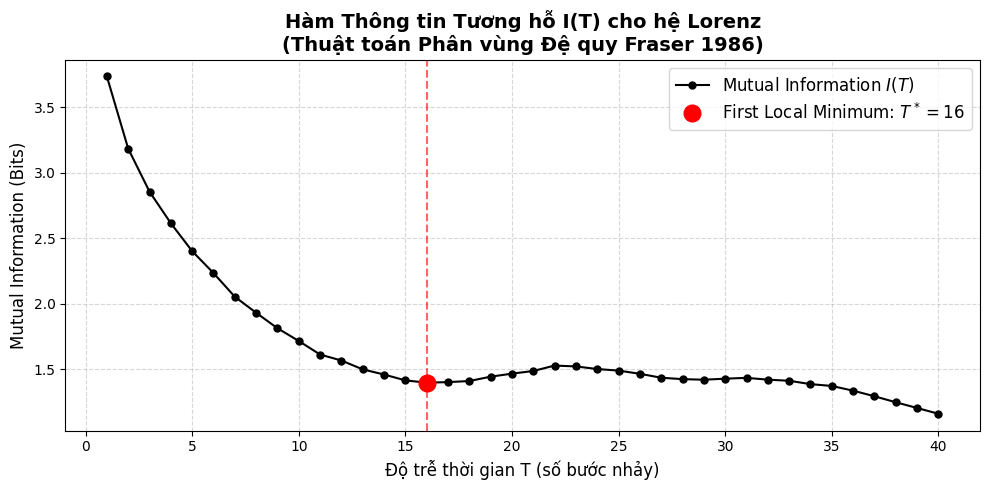

In [17]:
from scipy.stats import rankdata

# =====================================================================
# 2. CORE THUẬT TOÁN FRASER & SWINNEY (1986)
# =====================================================================

def calculate_F(x, y, x_min, x_max, y_min, y_max, depth=0):
    """Hàm đệ quy Quadtree tính cấu phần Entropy chưa chuẩn hóa (Phương trình 20a, 20b)"""
    N = len(x)
    
    # Điều kiện dừng an toàn để tránh tràn bộ nhớ hoặc mẫu quá nhỏ
    if N < 16 or depth > 8:
        return N * np.log2(N) if N > 0 else 0

    # Tính tọa độ trung điểm của ô lưới hiện tại
    x_mid = (x_min + x_max) / 2.0
    y_mid = (y_min + y_max) / 2.0
    
    # Phân loại các điểm dữ liệu vào 4 góc phần tư (quadrants)
    q1 = (x < x_mid) & (y < y_mid)
    q2 = (x >= x_mid) & (y < y_mid)
    q3 = (x < x_mid) & (y >= y_mid)
    q4 = (x >= x_mid) & (y >= y_mid)
    
    # Đếm số điểm rơi vào từng ô con (a_i)
    a = [np.sum(q1), np.sum(q2), np.sum(q3), np.sum(q4)]
    
    # Kiểm định Chi-square (Phương trình 21)
    expected = N / 4.0
    chi_square = sum((a_i - expected)**2 for a_i in a) / N
    
    # Ngưỡng ý nghĩa thống kê của Fraser (1.547)
    if chi_square <= 1.547:
        # Nhánh phẳng/Nhiễu -> Dừng cắt (Đóng nhanh)
        return N * np.log2(N)
    else:
        # Có cấu trúc nếp gấp -> Cắt làm 4 và tiếp tục đệ quy
        F_children = 0
        if a[0] > 0: F_children += calculate_F(x[q1], y[q1], x_min, x_mid, y_min, y_mid, depth+1)
        if a[1] > 0: F_children += calculate_F(x[q2], y[q2], x_mid, x_max, y_min, y_mid, depth+1)
        if a[2] > 0: F_children += calculate_F(x[q3], y[q3], x_min, x_mid, y_mid, y_max, depth+1)
        if a[3] > 0: F_children += calculate_F(x[q4], y[q4], x_mid, x_max, y_mid, y_max, depth+1)
        
        return N * np.log2(4) + F_children

def calculate_MI_for_delay(s, T):
    """Tính Mutual Information cho một độ trễ T cụ thể"""
    # 1. Tạo không gian trễ (Delay Coordinate)
    s_current = s[:-T]
    s_delayed = s[T:]
    N_points = len(s_current)
    
    # 2. Tiền xử lý: Rank Ordering -> Phân bố đều U(0,1)
    x_uniform = (rankdata(s_current) - 0.5) / N_points
    y_uniform = (rankdata(s_delayed) - 0.5) / N_points
    
    # 3. Kích hoạt Quadtree từ gốc tọa độ bao trùm toàn bộ [0,1]x[0,1]
    F_root = calculate_F(x_uniform, y_uniform, 0.0, 1.0, 0.0, 1.0)
    
    # 4. Tính giá trị MI cuối cùng (Phương trình 19)
    MI = (F_root / N_points) - np.log2(N_points)
    
    return max(0.0, MI) # Tránh sai số dấu phẩy động làm MI bị âm li ti

# =====================================================================
# 3. THỰC THI (EXECUTION) VÀ TÌM ĐIỂM CỰC TIỂU ĐẦU TIÊN
# =====================================================================
print("Đang chạy Quadtree quét qua các độ trễ T (có thể mất vài giây)...")

# Với dt = 0.01 của Lorenz, cực tiểu đầu tiên thường nằm ở khoảng T=10 đến T=20.
# Ta sẽ quét từ T=1 đến T=40 để thấy rõ cấu trúc.
T_values = np.arange(1, 41)
MI_values = []

for T in T_values:
    # Ở đây tôi đưa noisy_x vào để xem tính chống chịu nhiễu
    # Bạn có thể thay bằng clean_x để so sánh độ trễ tuyệt đối
    mi = calculate_MI_for_delay(noisy_x, T)
    MI_values.append(mi)

MI_values = np.array(MI_values)

# Thuật toán tìm Cực tiểu cục bộ đầu tiên (First Local Minimum)
first_local_min_idx = None
for i in range(1, len(MI_values) - 1):
    # Điều kiện: Điểm hiện tại thấp hơn điểm trước và thấp hơn điểm sau
    if MI_values[i] < MI_values[i-1] and MI_values[i] < MI_values[i+1]:
        first_local_min_idx = i
        break

optimal_T = T_values[first_local_min_idx] if first_local_min_idx is not None else T_values[0]
print(f"--> [KẾT QUẢ] Độ trễ T tối ưu (Cực tiểu đầu tiên) là: T = {optimal_T} (tương ứng {optimal_T * 0.01} giây)")

# =====================================================================
# 4. KẾT XUẤT ĐỒ THỊ (VISUALIZATION)
# =====================================================================
plt.figure(figsize=(10, 5))
plt.plot(T_values, MI_values, 'k.-', markersize=10, linewidth=1.5, label='Mutual Information $I(T)$')

if first_local_min_idx is not None:
    plt.plot(optimal_T, MI_values[first_local_min_idx], 'ro', markersize=12, 
             label=f'First Local Minimum: $T^* = {optimal_T}$')
    plt.axvline(x=optimal_T, color='red', linestyle='--', alpha=0.6)

plt.title("Hàm Thông tin Tương hỗ I(T) cho hệ Lorenz\n(Thuật toán Phân vùng Đệ quy Fraser 1986)", fontsize=14, fontweight='bold')
plt.xlabel("Độ trễ thời gian T (số bước nhảy)", fontsize=12)
plt.ylabel("Mutual Information (Bits)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Đang tái tạo không gian pha 3D cho các mốc T...


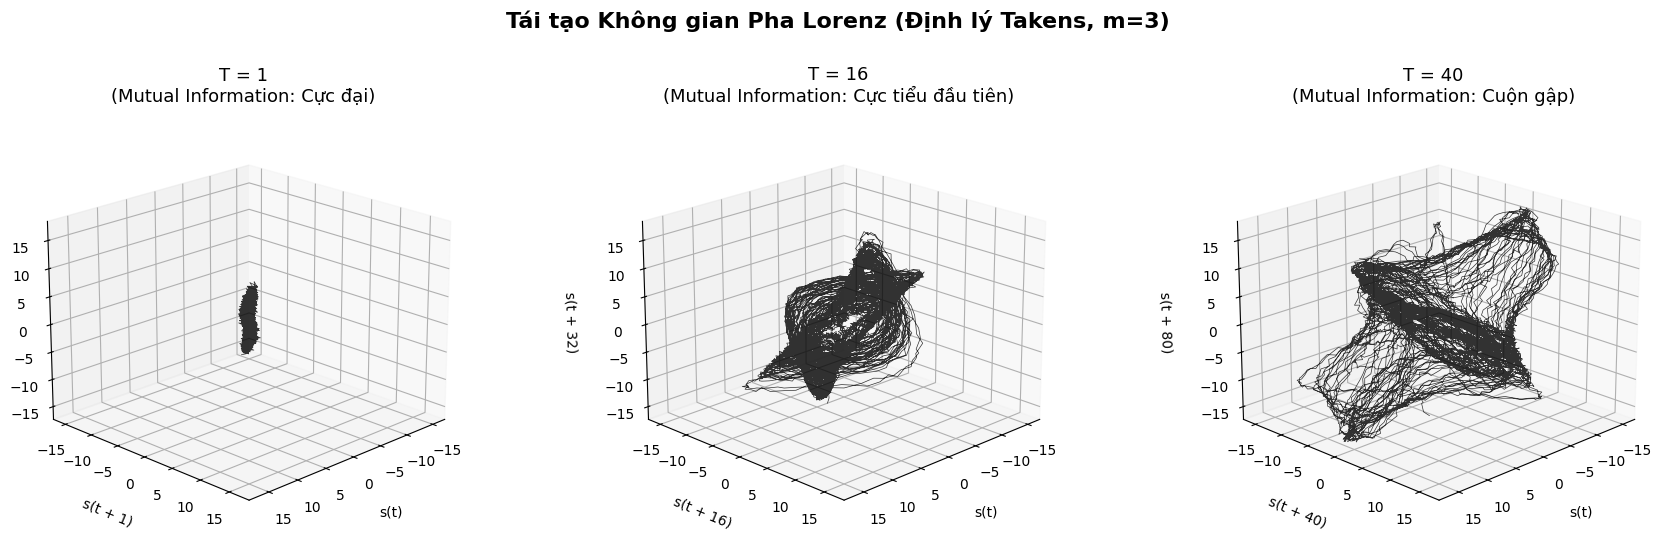

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =====================================================================
# 1. HÀM TÁI TẠO KHÔNG GIAN PHA (TAKENS' THEOREM)
# =====================================================================
def delay_coordinate_embedding(s, T, m=3):
    """
    Nhúng chuỗi thời gian 1D thành không gian pha m chiều với độ trễ T.
    """
    N = len(s) - (m - 1) * T
    # Khởi tạo ma trận không gian pha
    phase_space = np.zeros((N, m))
    
    for i in range(m):
        # Trượt chuỗi dữ liệu đi một đoạn i*T
        phase_space[:, i] = s[i*T : i*T + N]
        
    return phase_space

# =====================================================================
# 2. THỰC THI CHO 3 TRƯỜNG HỢP T VÀ TRỰC QUAN HÓA 3D
# =====================================================================
# Sử dụng clean_x để nhìn rõ cấu trúc topo, 
# hoặc noisy_x nếu muốn xem tác động của nhiễu. Ở đây dùng clean_x cho rõ.
s_data = noisy_x
T_test = [1, 16, 40]
m_dim = 3

print("Đang tái tạo không gian pha 3D cho các mốc T...")

fig = plt.figure(figsize=(18, 6))
fig.suptitle(f"Tái tạo Không gian Pha Lorenz (Định lý Takens, m={m_dim})", fontsize=16, fontweight='bold', y=0.95)

# Lặp qua 3 giá trị T
for i, T in enumerate(T_test):
    # Trích xuất các trục tọa độ
    X_embedded = delay_coordinate_embedding(s_data, T=T, m=m_dim)
    
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    # Vẽ quỹ đạo (vẽ dạng đường mỏng để thấy rõ cấu trúc)
    ax.plot(X_embedded[:, 0], X_embedded[:, 1], X_embedded[:, 2], 
            color='black', linewidth=0.5, alpha=0.8)
    
    # Thiết lập góc nhìn (Elevation, Azimuth) để thấy rõ hình cánh bướm
    ax.view_init(elev=20, azim=45)
    
    # Tùy chỉnh nhãn
    ax.set_title(f"T = {T}\n(Mutual Information: {'Cực đại' if i==0 else 'Cực tiểu đầu tiên' if i==1 else 'Cuộn gập'})", 
                 fontsize=13, color='darkred' if T==19 else 'black')
    ax.set_xlabel('s(t)', labelpad=10)
    ax.set_ylabel(f's(t + {T})', labelpad=10)
    ax.set_zlabel(f's(t + {2*T})', labelpad=10)
    
    # Đảm bảo tỷ lệ các trục bằng nhau để không bị bóp méo hình học
    max_range = np.array([X_embedded[:,0].max()-X_embedded[:,0].min(), 
                          X_embedded[:,1].max()-X_embedded[:,1].min(), 
                          X_embedded[:,2].max()-X_embedded[:,2].min()]).max() / 2.0
    mid_x = (X_embedded[:,0].max()+X_embedded[:,0].min()) * 0.5
    mid_y = (X_embedded[:,1].max()+X_embedded[:,1].min()) * 0.5
    mid_z = (X_embedded[:,2].max()+X_embedded[:,2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

# 📘 BÁO CÁO TOÁN HỌC: LÝ DO THUẬT TOÁN MI CỦA FRASER (1986) BỊ ĐÀO THẢI

Dù giải quyết thành công nghịch lý kích thước lưới (grid-size paradox) cho không gian 2 chiều vào thập niên 80, thuật toán Phân vùng Đệ quy (Adaptive Quadtree) của Fraser đã không thể trụ vững trước các yêu cầu của khoa học dữ liệu hiện đại. Dưới đây là 4 nguyên nhân cốt lõi:

## 1. Lời nguyền Số chiều (The Curse of Dimensionality)
* **Nguyên lý:** Trong không gian 2D, mỗi lần cắt, lưới đệ quy tạo ra $2^2 = 4$ ô con. Thuật toán hoạt động rất tốt để tìm độ trễ $\tau$ giữa cặp $(s_t, s_{t+\tau})$.
* **Sự sụp đổ:** Khi muốn tính Thông tin tương hỗ có điều kiện (Conditional MI) hoặc trích xuất đặc trưng phi tuyến từ không gian pha đa chiều để đưa vào các kiến trúc AI, thuật toán phải cắt lưới trong không gian $D$ chiều, sinh ra $2^D$ ô con (ví dụ: 10 chiều sẽ sinh ra $2^{10} = 1024$ ô).
* **Hậu quả:** Dữ liệu sẽ nhanh chóng bị "bốc hơi" trong không gian trống rỗng. Phần lớn các ô lưới sẽ có 0 hoặc 1 điểm. Bài kiểm tra $\chi^2$ hoàn toàn tê liệt vì không đủ số mẫu kỳ vọng (expected frequency) để ra quyết định, làm thuật toán thất bại hoàn toàn ở không gian chiều cao. 

## 2. Bất lực trước Dữ liệu Thực nghiệm Phi dừng (Non-stationarity)
* **Giả định gốc:** Thuật toán Fraser xây dựng hàm xác suất bằng cách đếm (histogram) trên toàn bộ chuỗi thời gian, ngầm giả định rằng hệ thống có tính Ergodic và phân bố bất biến (Stationary). Nó hoạt động tốt trên các phương trình toán học lý tưởng như Lorenz.
* **Thực tế lâm sàng/công nghiệp:** Khi phân tích các tín hiệu sinh lý học như PPG để nhận diện sự thay đổi trạng thái (ví dụ: chuyển từ tỉnh táo sang buồn ngủ), động lực học của hệ tim mạch là chuỗi các quá trình phi dừng biến thiên liên tục. Việc dùng một tấm lưới toàn cục duy nhất trùm lên toàn bộ dữ liệu sẽ trộn lẫn các phân bố xác suất của nhiều trạng thái khác nhau, làm kết quả $I(\tau)$ bị nhiễu loạn và mất đi ý nghĩa vật lý.

## 3. Sai số Hệ thống do Rời rạc hóa (Discretization Bias)
* **Nguyên lý:** Thuật toán tính MI gián tiếp thông qua 3 thành phần Entropy: 
  $$I(X,Y) = H(X) + H(Y) - H(X,Y)$$
* **Lỗ hổng:** Việc ép các quỹ đạo liên tục vào các ô vuông (dù là ô có kích thước linh hoạt) luôn tạo ra sai số lượng tử hóa (quantization error). Entropy của một biến liên tục phụ thuộc vào độ phân giải. Khi thực hiện phép cộng trừ $H(X) + H(Y) - H(X,Y)$, các sai số này **không hề tự triệt tiêu lẫn nhau**. Kết quả MI thu được luôn chứa một lượng bias (độ lệch) hệ thống khó kiểm soát, đặc biệt nhạy cảm với các nhiễu đo lường nhỏ.

## 4. Nút thắt Tính toán với Dữ liệu lớn (Scalability & Big Data)
* **Nguyên lý:** Cấu trúc Quadtree được coi là nhanh ($O(N \log N)$) vào năm 1986. Nhưng cấu trúc rẽ nhánh đệ quy (recursive branching) này liên tục đòi hỏi các phép kiểm định $\chi^2$ tại từng nút.
* **Rào cản hiện đại:** Khi áp dụng các kỹ thuật tổng hợp đặc trưng thời gian-tần số kết hợp phi tuyến trên các tập dữ liệu có quy mô lớn (chẳng hạn như việc chạy thực nghiệm trên hàng triệu điểm dữ liệu liên tục của phiên bản PhysDrive 2025), thao tác đệ quy (if/else liên tục) cực kỳ khó để lập trình song song hóa (parallelization) trên GPU. Nó trở thành nút thắt cổ chai làm chậm toàn bộ 파ipeline tiền xử lý của các mô hình học sâu.

---
**KẾT LUẬN:**
Sự kết hợp giữa *Sai số lượng tử hóa*, *Sự sụp đổ ở số chiều cao*, và *Khó khăn trong tính toán song song* đã buộc giới nghiên cứu phải tìm kiếm một phương pháp hoàn toàn mới: Tính MI không cần chia lưới (Grid-free), không qua trung gian Entropy (Direct Estimation), và dựa trên khoảng cách thay vì mật độ không gian. Đó chính là tiền đề cho sự thống trị của bộ ước lượng **k-Nearest Neighbors (KSG)** ra đời năm 2004.